# Run ArchesWeather models for AIMIP

In [2]:
%load_ext autoreload

In [28]:
%autoreload 2

In [3]:
cd ../..

/usr/local/google/home/singhren/coding/geoarches


In [4]:
from geoarches.lightning_modules import load_module

/usr/local/google/home/singhren/miniconda3/envs/geoarches/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load ArchesWeather

In [10]:
# load_module will look in modelstore/
model, config = load_module("aimip-archesweather-m-seed0")

##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure', 'sea_surface_temperature', 'sea_ice_cover'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Restored from modelstore/aimip-archesweather-m-seed0/checkpoints/checkpoint_global_step=300000.ckpt


In [51]:
# we can also load the 4-members deterministic ensemble ArchesWeather-Mx4 like so:

model, config = load_module(
    "aimip-archesweather-m-seed0",
    avg_with_modules=[
        "aimip-archesweather-m-seed1",
        "aimip-archesweather-m-seed2",
        "aimip-archesweather-m-seed3",
    ],
)

##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure', 'sea_surface_temperature', 'sea_ice_cover'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Loading avg modules: ['aimip-archesweather-m-seed1', 'aimip-archesweather-m-seed2', 'aimip-archesweather-m-seed3']
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure', 'sea_surface_temperature', 'sea_ice_cover'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Restored from modelstore/aimip-archesweather-m-seed1/checkpoints/checkpoint_global_st

## Era5 Dataloader

In [11]:
# load sample from dataloader with the aimip rollout domain
from geoarches.dataloaders.era5 import Era5Forecast

ds = Era5Forecast(
    stats_cfg=config.stats,
    path="data/era5_1x1/daily_averaged/",
    domain="aimip_rollout_z00",  # rollout domain (1978-2024 daily at 00h)
    lead_time_hours=24,
    load_prev=True,
    multistep=1,
    variables=config.stats.module.variables,
    dimension_indexers=dict(level=config.stats.module.levels),
    warning_on_nan=False,
    interpolate_input="zero_after_norm",
    forcings_path="data/era5_1x1/ERA5-0.25deg-monthly-mean-forcing-1978-2024_regridded_conservative_2025_11_03.nc",
    forcings_stats_path="ERA5-0.25deg-monthly-mean-forcing-1978-2013_regridded_conservative_norm_stats.nc",
    forcing_vars=["sea_surface_temperature", "sea_ice_cover"],
)

##### FORCINGS:  ['sea_surface_temperature', 'sea_ice_cover']  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure', 'sea_surface_temperature', 'sea_ice_cover'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
##### VARIABLES:  {'forcings': ['sea_surface_temperature', 'sea_ice_cover']}  #####
##### LEVELS:  None  #####


In [13]:
# The dataset returns a dict of TensorDict:
ic = ds[0]

print("keys in a sample:", ic.keys())
# a state contains level, surface, and forcing variables in a TensorDict
print("sample state:\n", ic["state"])

keys in a sample: dict_keys(['timestamp', 'hour_of_day', 'day_of_month', 'day_of_year', 'month', 'state', 'nan_mask', 'lead_time_hours', 'next_state', 'prev_state', 'forcings'])
sample state:
 TensorDict(
    fields={
        level: Tensor(shape=torch.Size([6, 13, 181, 360]), device=cpu, dtype=torch.float32, is_shared=False),
        surface: Tensor(shape=torch.Size([6, 1, 181, 360]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([6]),
    device=None,
    is_shared=False)


In [10]:
import pandas as pd

# First model prediction will be at 1978-10-01
pd.Timestamp(ic["timestamp"].item(), unit="s")

Timestamp('1978-09-30 00:00:00')

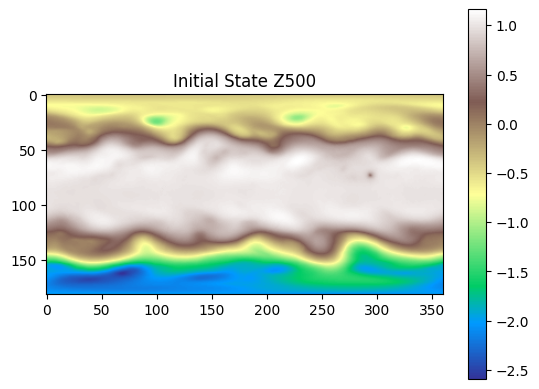

In [14]:
# we can visualize an initial condition sample, e.g. Z500, with the following
import matplotlib.pyplot as plt

plt.imshow(ic["state"]["level"][0, 7], cmap="terrain")
plt.colorbar()
plt.title("Initial State Z500")
plt.show()

## Run ArchesWeather

In [54]:
# now we can run 1-step inference with the deterministic model ArchesWeather:
import torch

torch.set_grad_enabled(False)

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = model.to(device)

batch = {k: v[None].to(device) for k, v in ic.items()}  # Add batch dimension.

pred = model(batch).cpu()

In [55]:
# optionally, we can denormalize the prediction to go back to real physical values
pred = ds.denormalize(pred)

24h Z500 prediction


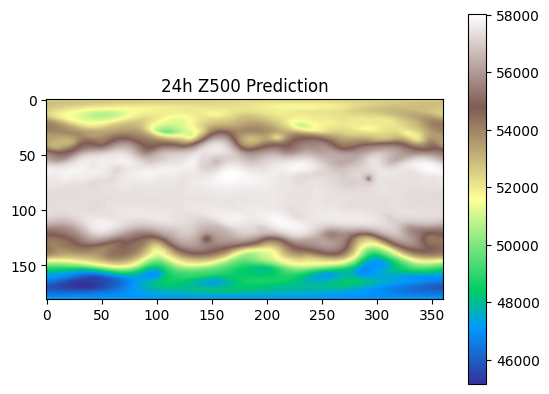

24h ground truth


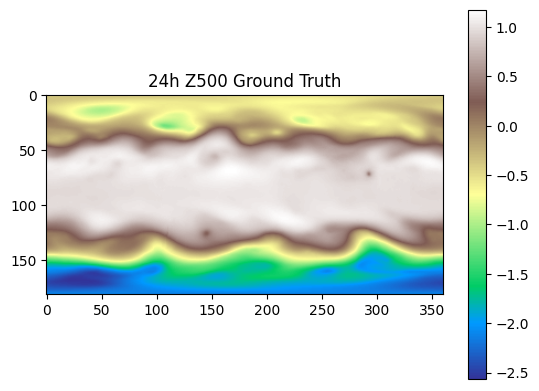

In [56]:
# we can visualize predictions, compared to ground truth

print("24h Z500 prediction")
plt.imshow(pred["level"][0, 0, 7], cmap="terrain")
plt.colorbar()
plt.title("24h Z500 Prediction")
plt.show()

print("24h ground truth")
plt.imshow(ic["next_state"]["level"][0, 7], cmap="terrain")
plt.colorbar()
plt.title("24h Z500 Ground Truth")
plt.show()

## Loading and running ArchesWeatherGen

In [7]:
# loading ArchesWeatherGen
import torch

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# load_module will look in modelstore/
gen_model, gen_config = load_module("aimip-archesweathergen")

gen_model = gen_model.to(device)

##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure', 'sea_surface_temperature', 'sea_ice_cover'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure', 'sea_surface_temperature', 'sea_ice_cover'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Restored from modelstore/aimip-archesweather-m-seed0/checkpoints/checkpoint_global_step=300000.ckpt
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature

In [14]:
# run model on a sample
seed = 0
num_steps = 25  # if not provided to model.sample, model will use the default value (25)

batch = {k: v[None].to(device) for k, v in ic.items()}


sample = gen_model.sample(batch, seed=seed, num_steps=num_steps).cpu()

100%|██████████| 25/25 [02:14<00:00,  5.40s/it]


24h Z500 prediction


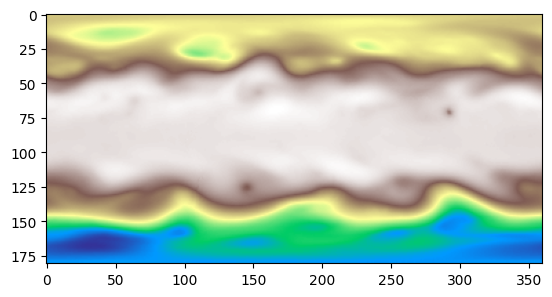

In [16]:
import matplotlib.pyplot as plt

print("24h Z500 prediction")
plt.imshow(sample["level"][0, 0, 7], cmap="terrain")
plt.show()